In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 6.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 5.3 MB/s eta 0:00:0000:0100:01m


In [3]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.sparse import hstack
import xgboost as xgb
from xgboost.sklearn import XGBClassifier # <3
from sklearn.model_selection import train_test_split
import gc

In [4]:
import re
import nltk
from nltk.corpus import stopwords
import pymorphy3
import pandas as pd

In [5]:
# Для русских текстов
morph = pymorphy3.MorphAnalyzer(lang='ru')
stop_words = set(stopwords.words('russian'))

def preprocess_text(text):
    # Удаление цензурных символов (****, ### и т.д.)
    text = re.sub(r'[*#]+', '', text)
    
    # Удаление спецсимволов, но сохранение основных знаков препинания
    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ0-9\s.,!?-]', ' ', text)
    
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Токенизация
    tokens = text.split()
    
    # Удаление стоп-слов и лемматизация
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words and len(token) > 2:
            lemma = morph.parse(token)[0].normal_form
            cleaned_tokens.append(lemma)
    
    return ' '.join(cleaned_tokens)

In [6]:
table_data = pd.read_excel("../../data_raw/DataSet_V49 (2).xlsx")

In [7]:
text_data = pd.read_csv("../../anonymized_parsed_data_analyzes.csv")

In [8]:
table_data.dropna(subset=['Смерть'], inplace=True)

In [9]:
df2_subset = table_data[['Файл(Анализы)', 'Смерть']]
df2_subset.rename(columns={'Файл(Анализы)': 'file_name', 'Смерть': 'label'}, inplace=True)

df2_subset["file_name"] = df2_subset["file_name"].astype(str)
# text_data['file_name'] = text_data['file_name'].apply(lambda x: str(int(x)) if pd.notna(x) else None)

# Делаем merge по идентификатору
df1 = text_data.merge(df2_subset, on='file_name', how='inner')

/tmp/ipykernel_2685631/3919788308.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_subset.rename(columns={'Файл(Анализы)': 'file_name', 'Смерть': 'label'}, inplace=True)
/tmp/ipykernel_2685631/3919788308.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_subset["file_name"] = df2_subset["file_name"].astype(str)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec, FastText

In [11]:
df1['anonymized_text_data'] = df1['anonymized_text_data'].apply(lambda x: preprocess_text(x))

In [13]:
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    stop_words='english',
    ngram_range=(1, 1),
    norm='l2',
    min_df=1.0,
    smooth_idf=False,
    max_features=15000)
word_vectorizer.fit(df1['anonymized_text_data'])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,'unicode'
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,"'\\w{1,}'"
,ngram_range,"(1, ...)"


In [15]:
X_texts = word_vectorizer.transform(df1['anonymized_text_data'])

In [20]:
df1["label"] = df1["label"].map({'Да': 1, 'Нет': 0})

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_texts, df1["label"], test_size=0.2, random_state=42, stratify=df1["label"]
)

In [22]:
train_word_features = word_vectorizer.transform(X_train)
test_word_features = word_vectorizer.transform(X_test)

AttributeError: 'csr_matrix' object has no attribute 'lower'

In [ ]:
d_test = xgb.DMatrix(test_word_features)

In [41]:
len(df1[df1["label"] == 0]["label"])

9130

In [42]:
sum(df1[df1["label"] == 1]["label"]) / len(df1[df1["label"] == 0]["label"])

0.03855421686746988

In [43]:
# X_train, X_valid, y_train, y_valid = train_test_split(
#     train_features, train_target, test_size=0.25, random_state=23)

xgb_params = {
    'eta': 0.3, 
    'max_depth': 5, 
    'subsample': 0.8, 
    'colsample_bytree': 0.8, 
    'objective': 'binary:logistic', 
    'eval_metric': 'auc', 
    'seed': 23,
    "scale_pos_weight": 0.03855421686746988
}

d_train = xgb.DMatrix(X_train, y_train)
d_valid = xgb.DMatrix(X_test, y_test)

watchlist = [(d_valid, 'valid')]
model = xgb.train(xgb_params, d_train, 200, watchlist, verbose_eval=False, early_stopping_rounds=30)
print(model.attributes())

pred = model.predict(d_valid)

{'best_iteration': '27', 'best_score': '0.9419344749394011'}


/opt/conda/lib/python3.11/site-packages/xgboost/core.py:771: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


In [68]:
labels = (pred > 0.01).astype(int)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

In [28]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

AttributeError: 'Booster' object has no attribute 'predict_proba'

In [69]:
auc = roc_auc_score(y_test, labels)
print(f"AUC на тесте: {auc:.4f}")

AUC на тесте: 0.8476


In [70]:
print(classification_report(y_test, labels))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1827
           1       0.59      0.71      0.65        70

    accuracy                           0.97      1897
   macro avg       0.79      0.85      0.82      1897
weighted avg       0.97      0.97      0.97      1897



In [62]:
res = []
for t in np.arange(0.0, 1.0 + 0.01, 0.01):
    labels = (pred > t).astype(int)
    auc = roc_auc_score(y_test, labels)
    res.append({"t": t, "auc": auc})

In [63]:
res.sort(key=lambda x: x['auc'], reverse=True)

In [67]:
for r in res:
    print(r["t"])

0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.11
0.1
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.31
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.0
0.99
1.0


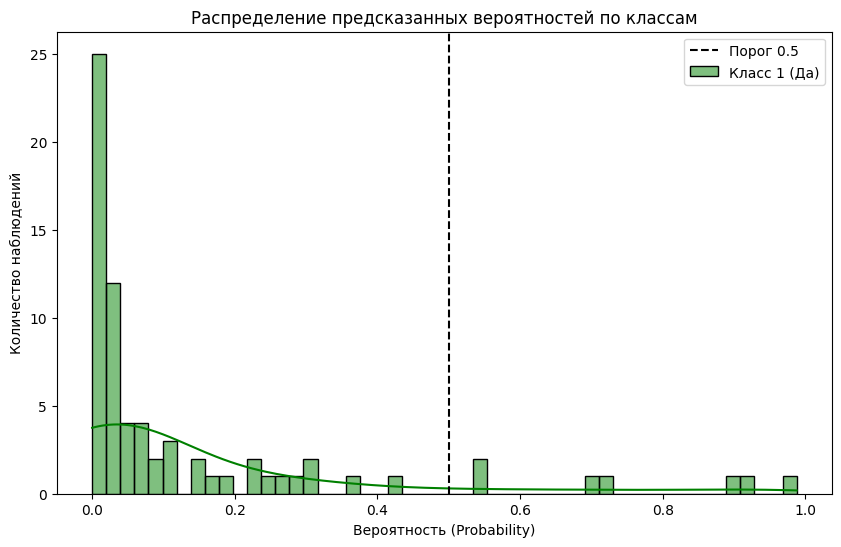

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Распределение для объектов первого класса
sns.histplot(pred[y_test == 1], bins=50, kde=True, color='green', label='Класс 1 (Да)', alpha=0.5)

plt.axvline(0.5, color='black', linestyle='--', label='Порог 0.5')
plt.title('Распределение предсказанных вероятностей по классам')
plt.xlabel('Вероятность (Probability)')
plt.ylabel('Количество наблюдений')
plt.legend()
plt.show()

In [ ]:


class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

train = pd.read_csv('../input/train.csv').fillna(' ')#.sample(1000)
test = pd.read_csv('../input/test.csv').fillna(' ')#.sample(1000)

train_text = train['comment_text']
test_text = test['comment_text']
all_text = pd.concat([train_text, test_text])

train = train.loc[:,class_names]

print("TFIDF")
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    stop_words='english',
    ngram_range=(1, 1),
    norm='l2',
    min_df=0,
    smooth_idf=False,
    max_features=15000)
word_vectorizer.fit(all_text)
train_word_features = word_vectorizer.transform(train_text)
test_word_features = word_vectorizer.transform(test_text)

char_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='char',
    stop_words='english',
    ngram_range=(2, 6),
    norm='l2',
    min_df=0,
    smooth_idf=False,
    max_features=50000)
char_vectorizer.fit(all_text)
train_char_features = char_vectorizer.transform(train_text)
test_char_features = char_vectorizer.transform(test_text)

train_features = hstack([train_char_features, train_word_features])
del train_char_features,train_word_features
test_features = hstack([test_char_features, test_word_features])
del test_char_features,test_word_features

print(train_features.shape)
print(test_features.shape)
d_test = xgb.DMatrix(test_features)
del test_features
gc.collect()

print("Modeling")
cv_scores = []
xgb_preds = []
submission = pd.DataFrame.from_dict({'id': test['id']})
for class_name in class_names:
    train_target = train[class_name]
    # Split out a validation set
    X_train, X_valid, y_train, y_valid = train_test_split(
        train_features, train_target, test_size=0.25, random_state=23)

    xgb_params = {'eta': 0.3, 
              'max_depth': 5, 
              'subsample': 0.8, 
              'colsample_bytree': 0.8, 
              'objective': 'binary:logistic', 
              'eval_metric': 'auc', 
              'seed': 23
             }

    d_train = xgb.DMatrix(X_train, y_train)
    d_valid = xgb.DMatrix(X_valid, y_valid)

    watchlist = [(d_valid, 'valid')]
    model = xgb.train(xgb_params, d_train, 200, watchlist, verbose_eval=False, early_stopping_rounds=30)
    print("class Name: {}".format(class_name))
    print(model.attributes()['best_msg'])
    cv_scores.append(float(model.attributes()['best_score']))
    submission[class_name] = model.predict(d_test)
    del X_train, X_valid, y_train, y_valid
    gc.collect()
print('Total CV score is {}'.format(np.mean(cv_scores)))
submission.to_csv('submission.csv', index=False)